# Module 9 – Activity – Discussion Group A (EN.705.623.81.SP26)

**Student:** Akira Hanada  
**Course:** AI Algorithm Design and Analysis – EN.705.623.81 – Spring 2026  
**Date:** March 29, 2026

In [14]:
# Import necessary libraries
import numpy as np                    # NumPy for numerical computation (arrays, linear algebra)
import pandas as pd                   # Pandas for tabular data display
import matplotlib.pyplot as plt       # Matplotlib for plotting charts and graphs
import matplotlib.patches as mpatches # Patches for custom legend entries in charts

---

## Question 1 — Thinking in Terms of Agent and Environment (Lecture 9A)

### Chosen Example: Autonomous Traffic Signal Control System

An autonomous traffic signal control system is a compelling example of an AI system that must make decisions over time. Unlike a simple timer-based traffic light that cycles through fixed intervals, an intelligent signal controller observes real-time traffic conditions and adjusts signal phases to optimize traffic flow, reduce congestion, and improve safety. This problem naturally maps onto the agent–environment framework introduced in Lecture 9A, where an agent perceives its surroundings through sensors and acts upon the environment through actuators, guided by a program that maps percepts to actions (Russell & Norvig, 2021, Chapter 2).

**The Agent** in this scenario is the traffic signal controller itself — a software system embedded in the intersection's hardware. It receives sensor data and decides which signal phase to display at each decision point. **The Environment** consists of the intersection and all approaching roadways, including the vehicles, pedestrians, and other traffic participants whose behavior is partially stochastic and not fully controllable by the agent.

The following table summarizes the key components of the agent–environment framework applied to this problem:

| Component | Description |
|---|---|
| **Agent** | Autonomous traffic signal controller |
| **Environment** | Road intersection with approaching vehicles, pedestrians, and cross-traffic |
| **States** | Queue lengths on each approach, current signal phase, time since last phase change, time of day, presence of emergency vehicles |
| **Actions** | Extend current green phase, switch to next phase, activate pedestrian crossing, preempt for emergency vehicle |
| **Percepts** | Vehicle counts from inductive loop detectors or cameras, pedestrian push-button requests, emergency vehicle transponder signals |
| **Rewards / Goals** | Minimize average vehicle delay, minimize total queue length, ensure pedestrian safety, prioritize emergency vehicles |

This is fundamentally a **sequential decision-making problem** rather than a one-step prediction problem. A one-step prediction would simply classify the current traffic state or estimate queue length at a single moment. In contrast, the traffic controller must reason about chains of decisions over time: extending a green phase now may clear one approach but cause queues to build on the cross-street, leading to worse congestion in subsequent cycles. Every action the agent takes changes the state of the environment, which in turn affects what future states and rewards are available. This temporal dependency is exactly what distinguishes sequential decision-making from static classification or regression tasks (Sutton & Barto, 2018, Chapter 3).

A **policy** — a mapping from states to actions — is essential because it provides the agent with a consistent strategy for all possible situations it might encounter. Rather than making each decision in isolation, a good policy accounts for the long-term consequences of actions. For instance, a myopic policy might always give green to the approach with the longest queue, but a far-sighted policy would consider that allowing a short phase for a lightly trafficked approach now prevents those vehicles from growing into a large queue by the next cycle. The policy allows the agent to balance immediate throughput against future congestion.

The **discount factor** plays a meaningful role here. Future rewards matter significantly because traffic is a continuous process — vehicles that are not served now do not disappear; they accumulate and create compounding delays. A discount factor close to 1 (e.g., $\gamma = 0.95$) is appropriate because the agent should care about throughput not just in the current cycle but across many future cycles. However, some discounting is still necessary because predictions about far-future traffic become less reliable due to stochastic arrivals and changing demand patterns. In reinforcement learning terms, the agent must balance exploitation of currently known traffic patterns with the uncertainty inherent in long-horizon planning (Sutton & Barto, 2018, Chapter 3).

This example connects directly to the module's theme: the traffic signal controller is an agent that must choose actions repeatedly, observe outcomes, and reason about long-term consequences — precisely the setting that Markov Decision Processes are designed to formalize.

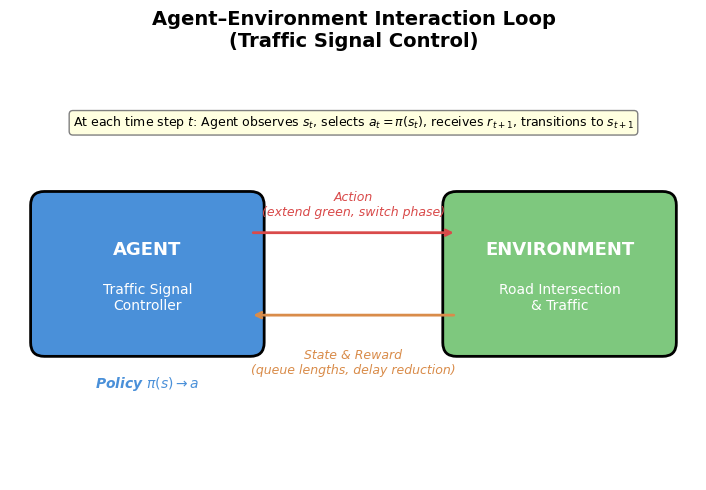

In [15]:
# ── Q1: Visualization — Agent–Environment Interaction Diagram ──

fig, ax = plt.subplots(figsize=(10, 5))                        # Create a figure with specified size
ax.set_xlim(0, 10)                                             # Set x-axis limits for layout
ax.set_ylim(0, 6)                                              # Set y-axis limits for layout
ax.set_aspect('equal')                                         # Equal aspect ratio for clean boxes
ax.axis('off')                                                 # Turn off axis lines and ticks
ax.set_title('Agent–Environment Interaction Loop\n(Traffic Signal Control)',
             fontsize=14, fontweight='bold', pad=15)            # Title describing the diagram

# Draw the Agent box (left side)
agent_box = mpatches.FancyBboxPatch((0.5, 2), 3, 2,           # Position (x, y), width, height
    boxstyle='round,pad=0.2', facecolor='#4A90D9',            # Rounded corners, blue fill
    edgecolor='black', linewidth=2)                            # Black border
ax.add_patch(agent_box)                                        # Add the patch to the axes
ax.text(2, 3.35, 'AGENT', ha='center', va='center',           # Label at center of box
        fontsize=13, fontweight='bold', color='white')         # White bold text
ax.text(2, 2.65, 'Traffic Signal\nController', ha='center',   # Sub-label describing the agent
        va='center', fontsize=10, color='white')               # Smaller white text

# Draw the Environment box (right side)
env_box = mpatches.FancyBboxPatch((6.5, 2), 3, 2,             # Position for the environment box
    boxstyle='round,pad=0.2', facecolor='#7EC87E',            # Green fill for environment
    edgecolor='black', linewidth=2)                            # Black border
ax.add_patch(env_box)                                          # Add the patch to the axes
ax.text(8, 3.35, 'ENVIRONMENT', ha='center', va='center',     # Label for environment
        fontsize=13, fontweight='bold', color='white')         # White bold text
ax.text(8, 2.65, 'Road Intersection\n& Traffic', ha='center', # Sub-label
        va='center', fontsize=10, color='white')               # Smaller white text

# Arrow: Agent → Environment (Action — top arrow going right)
ax.annotate('', xy=(6.5, 3.6), xytext=(3.5, 3.6),            # Arrow from agent to environment (top)
            arrowprops=dict(arrowstyle='->', lw=2, color='#D94A4A'))  # Red arrow
ax.text(5, 4.0, 'Action\n(extend green, switch phase)',       # Label above the arrow
        ha='center', va='center', fontsize=9, color='#D94A4A',# Red text matching arrow
        fontstyle='italic')                                    # Italic for distinction

# Arrow: Environment → Agent (Percept + Reward — bottom arrow going left)
ax.annotate('', xy=(3.5, 2.4), xytext=(6.5, 2.4),            # Arrow from environment to agent (bottom)
            arrowprops=dict(arrowstyle='->', lw=2, color='#D98C4A'))  # Orange arrow
ax.text(5, 1.7, 'State & Reward\n(queue lengths, delay reduction)',  # Label below the arrow
        ha='center', va='center', fontsize=9, color='#D98C4A',       # Orange text
        fontstyle='italic')                                           # Italic style

# Add a "Policy π" label inside the agent box area
ax.text(2, 1.4, r'Policy $\pi(s) \rightarrow a$', ha='center',  # Policy notation below agent
        va='center', fontsize=10, color='#4A90D9',                 # Blue text matching agent
        fontstyle='italic', fontweight='bold')                     # Bold italic

# Add time-step annotation
ax.text(5, 5.2, r'At each time step $t$: Agent observes $s_t$, '
        r'selects $a_t = \pi(s_t)$, receives $r_{t+1}$, transitions to $s_{t+1}$',
        ha='center', va='center', fontsize=9,                      # Explanatory text at top
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='gray'))                                # Yellow box for emphasis

plt.tight_layout()                                                 # Adjust layout to prevent clipping
plt.show()                                                         # Display the diagram

The diagram above illustrates the core agent–environment interaction loop as described in Russell and Norvig (2021, Chapter 2). At each time step, the agent (traffic signal controller) observes the current state of the environment (queue lengths, current phase, etc.), selects an action according to its policy $\pi$, and receives a reward signal reflecting how well that action served the goal of minimizing delay. The environment then transitions to a new state, and the cycle repeats — forming the sequential decision-making loop that motivates the MDP framework in the next lecture.

---

## Question 2 — Modeling an MDP (Lecture 9B)

### Formalizing the Traffic Signal Controller as a Markov Decision Process

In Question 1, we described an autonomous traffic signal controller using the intuitive agent–environment framework. We now take this example one step further and express it formally as a Markov Decision Process (MDP), defined by the tuple $(S, A, P, R, \gamma)$ (Russell & Norvig, 2021, Chapter 17). To keep the formalization tractable, we simplify the real-world intersection to a two-approach intersection (North–South and East–West) where the controller must decide which direction to give the green light.

**States ($S$):** Each state encodes the traffic condition at the intersection. We define states as tuples of discretized queue lengths on each approach. For simplicity, suppose each approach can have a queue of Low (L), Medium (M), or High (H) vehicles. A state is thus a pair like (NS=Low, EW=High), yielding $3 \times 3 = 9$ possible states. The current signal phase (which direction is green) is also part of the state representation, doubling it to 18 states. This is a deliberate simplification; real systems would include time-of-day and other features.

**Actions ($A$):** At each decision epoch, the controller chooses one of two actions: **keep** the current green direction, or **switch** to the other direction. Formally, $A = \{\text{keep}, \text{switch}\}$.

**Transition Function ($P$):** The transition probability $P(s' | s, a)$ captures how the traffic state evolves after an action. If the current state is (NS=High, EW=Low, green=NS) and the agent chooses "keep," the NS queue is likely to decrease (vehicles are served) while the EW queue may increase (vehicles arrive but are not served). These transitions are stochastic because vehicle arrivals are random. For example, $P(\text{(NS=M, EW=M, green=NS)} | \text{(NS=H, EW=L, green=NS)}, \text{keep}) = 0.6$, reflecting that keeping green for NS likely reduces the NS queue while the EW queue grows from Low to Medium with some probability.

**Reward Function ($R$):** The reward function quantifies the objective. We define $R(s, a)$ as the negative of total delay across both approaches after the action. If keeping the green clears five NS vehicles while only two EW vehicles arrive, the net delay reduction is positive (reward is less negative). Switching has a cost because the yellow-and-all-red clearance interval adds delay. The reward structure thus penalizes congestion and unnecessary switching.

**Discount Factor ($\gamma = 0.9$):** We use $\gamma = 0.9$ to reflect that future traffic conditions matter but become less predictable over longer horizons. This balances short-term throughput with long-term congestion avoidance.

The following table summarizes the formal MDP components:

| MDP Component | Formal Definition | Traffic Signal Interpretation |
|---|---|---|
| States $S$ | $\{(q_{NS}, q_{EW}, \phi) : q \in \{L, M, H\}, \phi \in \{NS, EW\}\}$ | Queue levels on each approach plus current green phase |
| Actions $A$ | $\{\text{keep}, \text{switch}\}$ | Maintain current phase or switch |
| Transitions $P(s'|s,a)$ | Stochastic; depends on arrival/departure rates | Queue evolution under traffic flow dynamics |
| Rewards $R(s,a)$ | $-\text{total\_delay}(s, a)$ | Negative delay; less congestion = higher reward |
| Discount $\gamma$ | 0.9 | Future cycles matter but are discounted |

**Markov Property:** The state definition appears to satisfy the Markov property because, given the current queue lengths and signal phase, the future evolution of traffic depends only on the current state and the chosen action — not on the history of how the intersection arrived at that state. The queue lengths summarize all relevant past traffic arrivals and departures. However, in reality, the Markov property is an approximation: real traffic exhibits temporal correlations (e.g., platoons from upstream signals) that are not fully captured by instantaneous queue lengths. Including additional features like time-of-day would strengthen the Markov assumption at the cost of a larger state space.

**State Value and Action Value:** The state value $V^\pi(s)$ represents the expected cumulative discounted reward (i.e., negative delay) the controller will accumulate starting from state $s$ and following policy $\pi$. A state with low queues on both approaches and the green serving the busier direction would have a high value because future delays are expected to be small. The action value $Q^\pi(s, a)$ represents the expected cumulative reward from taking action $a$ in state $s$ and then following policy $\pi$. For example, $Q^\pi((\text{NS=H, EW=L, green=NS}), \text{keep})$ tells us how good it is to continue serving the heavy NS queue — likely high because it reduces congestion immediately.

**Bellman Equation and Long-Term Decision Quality:** The Bellman equation, $V^*(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^*(s') \right]$, is the mathematical backbone that connects immediate rewards to long-term decision quality (Russell & Norvig, 2021, Chapter 17). It states that the optimal value of a state equals the best immediate reward achievable plus the discounted expected value of the next state. In our traffic example, this means the controller should not simply minimize delay in the current cycle; it should choose the action whose immediate reward plus the expected future value of the resulting traffic state is highest. For instance, switching to serve a currently light EW queue might yield a small immediate reward, but if it prevents the EW queue from growing into a High state (which would cause large future delays), the Bellman equation captures that downstream benefit. This recursive decomposition allows the agent to reason about infinite-horizon consequences through a single equation. Compared to the intuitive description from Module 9A, the formal MDP view provides precise mathematical machinery — the transition function, reward function, and Bellman equation — that transforms vague notions of "planning ahead" into computable quantities that can be solved algorithmically through value iteration or policy iteration.

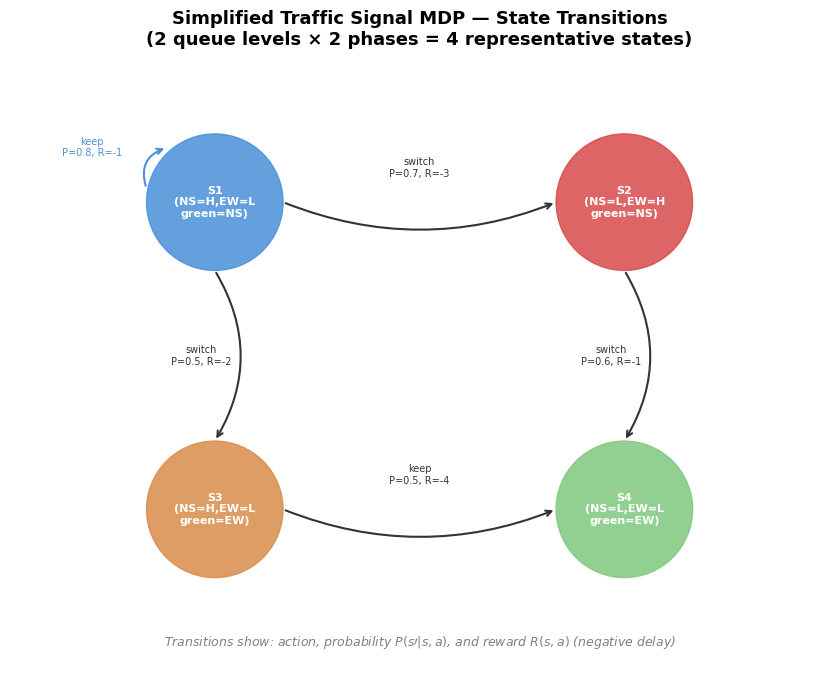

In [16]:
# ── Q2: Visualization — Simplified MDP State-Transition Diagram ──

fig, ax = plt.subplots(figsize=(11, 7))                        # Create figure for MDP diagram
ax.set_xlim(-1, 11)                                            # Set x-axis range
ax.set_ylim(-1, 8)                                             # Set y-axis range
ax.set_aspect('equal')                                         # Equal aspect so circles look round
ax.axis('off')                                                 # Hide axis
ax.set_title('Simplified Traffic Signal MDP — State Transitions\n'
             '(2 queue levels × 2 phases = 4 representative states)',
             fontsize=13, fontweight='bold', pad=15)            # Descriptive title

# Define 4 representative states with positions for the diagram
states_info = {
    'S1\n(NS=H,EW=L\ngreen=NS)': (2, 6),                      # Top-left: heavy NS, light EW, green NS
    'S2\n(NS=L,EW=H\ngreen=NS)': (8, 6),                      # Top-right: light NS, heavy EW, green NS
    'S3\n(NS=H,EW=L\ngreen=EW)': (2, 1.5),                    # Bottom-left: heavy NS, light EW, green EW
    'S4\n(NS=L,EW=L\ngreen=EW)': (8, 1.5),                    # Bottom-right: balanced, green EW
}

colors = ['#4A90D9', '#D94A4A', '#D98C4A', '#7EC87E']         # Colors for each state circle

# Draw state circles
for (label, (cx, cy)), color in zip(states_info.items(), colors):
    circle = plt.Circle((cx, cy), 1.0, color=color, alpha=0.85) # Circle with radius 1.0
    ax.add_patch(circle)                                         # Add to axes
    ax.text(cx, cy, label, ha='center', va='center',             # State label at center
            fontsize=8, fontweight='bold', color='white')         # White bold text

# Draw selected transitions as arrows with action/probability labels
transitions = [
    # (from_xy, to_xy, label, color, curvature)
    ((3.0, 6.0), (7.0, 6.0), 'switch\nP=0.7, R=-3', '#333', 'arc3,rad=0.2'),   # S1→S2
    ((2.0, 5.0), (2.0, 2.5), 'switch\nP=0.5, R=-2', '#333', 'arc3,rad=-0.3'),  # S1→S3
    ((8.0, 5.0), (8.0, 2.5), 'switch\nP=0.6, R=-1', '#333', 'arc3,rad=-0.3'),  # S2→S4
    ((3.0, 1.5), (7.0, 1.5), 'keep\nP=0.5, R=-4', '#333', 'arc3,rad=0.2'),     # S3→S4
]

for (x1, y1), (x2, y2), label, color, style in transitions:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),               # Arrow between states
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.5, connectionstyle=style))  # Curved arrow
    mx, my = (x1+x2)/2, (y1+y2)/2                               # Midpoint for label placement
    offset = 0.5 if 'rad=0.2' in style else -0.5                 # Offset label based on curvature
    if x1 == x2:                                                 # Vertical arrow
        ax.text(mx + offset + 0.3, my, label, ha='center',
                va='center', fontsize=7, color=color)
    else:                                                        # Horizontal arrow
        ax.text(mx, my + offset, label, ha='center',
                va='center', fontsize=7, color=color)

# Self-loop annotation for S1 (keep action)
ax.annotate('', xy=(1.3, 6.8), xytext=(1.0, 6.2),              # Self-loop arrow
            arrowprops=dict(arrowstyle='->', color='#4A90D9',
                            lw=1.5, connectionstyle='arc3,rad=-0.5'))
ax.text(0.2, 6.8, 'keep\nP=0.8, R=-1', fontsize=7,            # Label for self-loop
        ha='center', va='center', color='#4A90D9')

# Legend
ax.text(5, -0.5, r'Transitions show: action, probability $P(s\prime|s,a)$, '
        r'and reward $R(s,a)$ (negative delay)',
        ha='center', fontsize=9, fontstyle='italic', color='gray')  # Caption

plt.tight_layout()                                                   # Adjust layout
plt.show()                                                           # Display the diagram

The diagram above shows a subset of states and transitions for the simplified traffic signal MDP. Each circle represents a state encoding queue levels and current green phase. Arrows represent transitions labeled with the action, transition probability $P(s'|s,a)$, and immediate reward $R(s,a)$. The self-loop on S1 illustrates that keeping the green for the busy direction often maintains the same state with modest negative delay. The Bellman equation recursively aggregates these transition probabilities and rewards to compute the optimal long-term value of each state.

---

## Question 3 — Value Iteration and Policy Extraction (Lecture 9C)

### Problem Setup

We are given a small MDP with four states — S1, S2, S3, and Goal — where Goal is a terminal state with value 0. The agent has two actions available in each non-terminal state, and all transitions are deterministic. The discount factor is $\gamma = 0.9$, and all state values are initialized to 0. Our task is to perform two iterations of value iteration using the Bellman optimality equation and then extract the optimal policy.

The Bellman optimality equation for deterministic transitions simplifies to:

$$V_{k+1}(s) = \max_a \left[ R(s, a) + \gamma \cdot V_k(s') \right]$$

where $s'$ is the state reached after taking action $a$ from state $s$, $R(s,a)$ is the immediate reward, and $\gamma$ is the discount factor (Russell & Norvig, 2021, Chapter 17). Because each action leads deterministically to a single next state, the summation over $s'$ reduces to a single term.

The following table summarizes the transitions and rewards:

| From State | Action | Next State | Reward |
|---|---|---|---|
| S1 | a | S2 | 2 |
| S1 | b | S3 | 1 |
| S2 | a | Goal | 5 |
| S2 | b | S3 | 0 |
| S3 | a | Goal | 3 |
| S3 | b | S2 | 1 |

In [17]:
# ── Q3: Value Iteration — Setup ──

# Define the MDP transitions as a dictionary
# Format: mdp[state][action] = (next_state, reward)
mdp = {                                                        # Dictionary encoding the MDP
    'S1': {'a': ('S2', 2), 'b': ('S3', 1)},                   # From S1: action a→S2 (r=2), b→S3 (r=1)
    'S2': {'a': ('Goal', 5), 'b': ('S3', 0)},                 # From S2: action a→Goal (r=5), b→S3 (r=0)
    'S3': {'a': ('Goal', 3), 'b': ('S2', 1)},                 # From S3: action a→Goal (r=3), b→S2 (r=1)
}

gamma = 0.9                                                    # Discount factor γ = 0.9
states = ['S1', 'S2', 'S3']                                   # Non-terminal states
V = {'S1': 0.0, 'S2': 0.0, 'S3': 0.0, 'Goal': 0.0}          # Initialize all values to 0

print('Initial values:', {s: V[s] for s in states})            # Display initial values

Initial values: {'S1': 0.0, 'S2': 0.0, 'S3': 0.0}


In [18]:
# ── Q3: Value Iteration — Iteration 1 ──

# Store iteration history for display
iteration_history = []                                          # List to store results per iteration

print('='*70)                                                   # Separator
print('ITERATION 1')                                            # Header
print('='*70)                                                   # Separator

new_V = V.copy()                                                # Copy current values for synchronous update
iter1_details = {}                                              # Store detailed calculations

for s in states:                                                # Loop over each non-terminal state
    q_values = {}                                               # Dictionary for Q-values of each action
    for a, (s_next, r) in mdp[s].items():                      # For each action from this state
        q = r + gamma * V[s_next]                               # Bellman update: R + γ·V(s')
        q_values[a] = q                                         # Store Q-value for this action
        print(f'  V({s}) via action {a}: R({s},{a}) + γ·V({s_next}) '
              f'= {r} + {gamma}×{V[s_next]:.2f} = {q:.2f}')    # Print detailed calculation
    best_a = max(q_values, key=q_values.get)                    # Find action with highest Q-value
    new_V[s] = q_values[best_a]                                 # Update value to max Q-value
    iter1_details[s] = q_values                                 # Save details
    print(f'  → V₁({s}) = max({q_values}) = {new_V[s]:.2f}')   # Print result
    print()                                                     # Blank line for readability

V = new_V                                                       # Apply the updated values
iteration_history.append({s: V[s] for s in states})             # Record iteration 1 values

print('Values after Iteration 1:', {s: round(V[s], 4) for s in states})  # Summary

ITERATION 1
  V(S1) via action a: R(S1,a) + γ·V(S2) = 2 + 0.9×0.00 = 2.00
  V(S1) via action b: R(S1,b) + γ·V(S3) = 1 + 0.9×0.00 = 1.00
  → V₁(S1) = max({'a': 2.0, 'b': 1.0}) = 2.00

  V(S2) via action a: R(S2,a) + γ·V(Goal) = 5 + 0.9×0.00 = 5.00
  V(S2) via action b: R(S2,b) + γ·V(S3) = 0 + 0.9×0.00 = 0.00
  → V₁(S2) = max({'a': 5.0, 'b': 0.0}) = 5.00

  V(S3) via action a: R(S3,a) + γ·V(Goal) = 3 + 0.9×0.00 = 3.00
  V(S3) via action b: R(S3,b) + γ·V(S2) = 1 + 0.9×0.00 = 1.00
  → V₁(S3) = max({'a': 3.0, 'b': 1.0}) = 3.00

Values after Iteration 1: {'S1': 2.0, 'S2': 5.0, 'S3': 3.0}


In [19]:
# ── Q3: Value Iteration — Iteration 2 ──

print('='*70)                                                   # Separator
print('ITERATION 2')                                            # Header
print('='*70)                                                   # Separator

new_V = V.copy()                                                # Copy current values for synchronous update
iter2_details = {}                                              # Store detailed calculations

for s in states:                                                # Loop over each non-terminal state
    q_values = {}                                               # Dictionary for Q-values of each action
    for a, (s_next, r) in mdp[s].items():                      # For each action from this state
        q = r + gamma * V[s_next]                               # Bellman update: R + γ·V(s')
        q_values[a] = q                                         # Store Q-value for this action
        print(f'  V({s}) via action {a}: R({s},{a}) + γ·V({s_next}) '
              f'= {r} + {gamma}×{V[s_next]:.2f} = {q:.2f}')    # Print detailed calculation
    best_a = max(q_values, key=q_values.get)                    # Find action with highest Q-value
    new_V[s] = q_values[best_a]                                 # Update value to max Q-value
    iter2_details[s] = q_values                                 # Save details
    print(f'  → V₂({s}) = max({q_values}) = {new_V[s]:.2f}')   # Print result
    print()                                                     # Blank line

V = new_V                                                       # Apply the updated values
iteration_history.append({s: V[s] for s in states})             # Record iteration 2 values

print('Values after Iteration 2:', {s: round(V[s], 4) for s in states})  # Summary

ITERATION 2
  V(S1) via action a: R(S1,a) + γ·V(S2) = 2 + 0.9×5.00 = 6.50
  V(S1) via action b: R(S1,b) + γ·V(S3) = 1 + 0.9×3.00 = 3.70
  → V₂(S1) = max({'a': 6.5, 'b': 3.7}) = 6.50

  V(S2) via action a: R(S2,a) + γ·V(Goal) = 5 + 0.9×0.00 = 5.00
  V(S2) via action b: R(S2,b) + γ·V(S3) = 0 + 0.9×3.00 = 2.70
  → V₂(S2) = max({'a': 5.0, 'b': 2.7}) = 5.00

  V(S3) via action a: R(S3,a) + γ·V(Goal) = 3 + 0.9×0.00 = 3.00
  V(S3) via action b: R(S3,b) + γ·V(S2) = 1 + 0.9×5.00 = 5.50
  → V₂(S3) = max({'a': 3.0, 'b': 5.5}) = 5.50

Values after Iteration 2: {'S1': 6.5, 'S2': 5.0, 'S3': 5.5}


In [20]:
# ── Q3: Policy Extraction ──

print('='*70)                                                    # Separator
print('POLICY EXTRACTION (based on V after Iteration 2)')        # Header
print('='*70)                                                    # Separator

policy = {}                                                      # Dictionary for optimal policy

for s in states:                                                 # Loop over non-terminal states
    q_values = {}                                                # Compute Q-values under current V
    for a, (s_next, r) in mdp[s].items():                       # For each action
        q_values[a] = r + gamma * V[s_next]                      # Q(s,a) = R + γ·V(s')
    best_a = max(q_values, key=q_values.get)                     # Best action = argmax Q
    policy[s] = best_a                                           # Store in policy
    q_str = ', '.join(f'{k}: {v:.4f}' for k, v in q_values.items())  # Format Q-values
    print(f'  π*({s}): Q-values = {{{q_str}}}  →  best action = {best_a}')  # Show best action

print()
print('Optimal Policy:', policy)                                 # Display the extracted policy

POLICY EXTRACTION (based on V after Iteration 2)
  π*(S1): Q-values = {a: 6.5000, b: 5.9500}  →  best action = a
  π*(S2): Q-values = {a: 5.0000, b: 4.9500}  →  best action = a
  π*(S3): Q-values = {a: 3.0000, b: 5.5000}  →  best action = b

Optimal Policy: {'S1': 'a', 'S2': 'a', 'S3': 'b'}


In [21]:
# ── Q3: Summary Table ──

# Build a summary DataFrame showing values across iterations and the final policy
summary_data = {                                                   # Dictionary for table rows
    'State': states,                                               # State names
    'V₀ (init)': [0.0, 0.0, 0.0],                                 # Initial values
    'V₁ (iter 1)': [iteration_history[0][s] for s in states],      # Values after iteration 1
    'V₂ (iter 2)': [iteration_history[1][s] for s in states],      # Values after iteration 2
    'π* (best action)': [policy[s] for s in states],               # Optimal action
}

df_summary = pd.DataFrame(summary_data)                            # Create DataFrame
df_summary = df_summary.set_index('State')                         # Set State as index
print(df_summary.to_string())                                      # Print the summary table

       V₀ (init)  V₁ (iter 1)  V₂ (iter 2) π* (best action)
State                                                      
S1           0.0          2.0          6.5                a
S2           0.0          5.0          5.0                a
S3           0.0          3.0          5.5                b


C:\Users\akira\AppData\Local\Temp\ipykernel_45236\1356814917.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((cx, cy), 0.6, color=node_colors[s_name],    # Circle at position


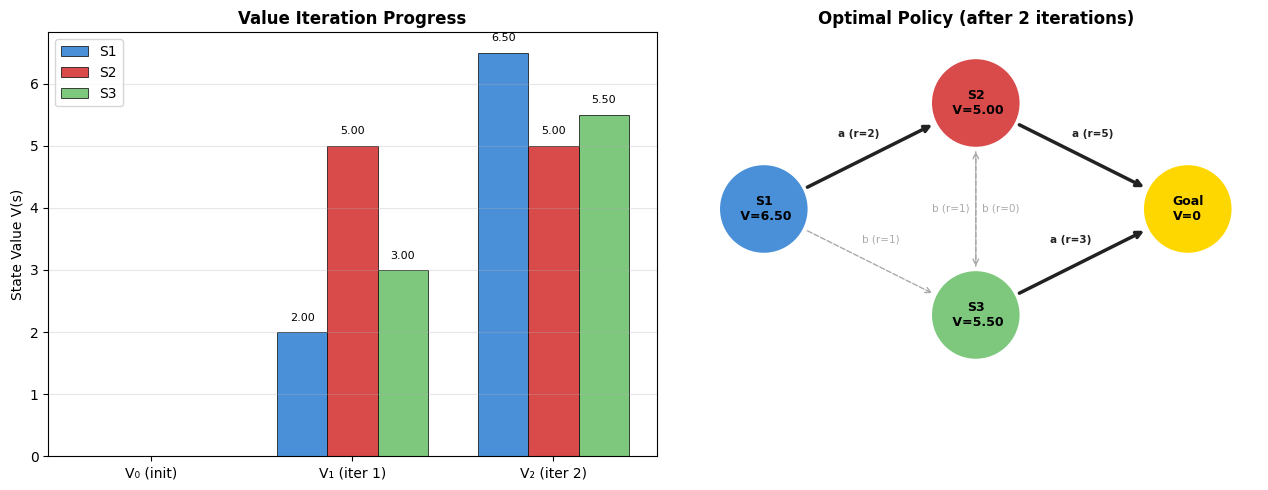

In [22]:
# ── Q3: Visualization — Value Iteration Convergence Chart ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))                   # Two subplots side by side

# --- Left: Bar chart of values across iterations ---
ax1 = axes[0]                                                      # First subplot
iterations_labels = ['V₀ (init)', 'V₁ (iter 1)', 'V₂ (iter 2)']   # X-axis labels
x_pos = np.arange(len(iterations_labels))                          # X positions
width = 0.25                                                       # Bar width

all_vals = [[0, 0, 0]]                                             # Start with initial values
all_vals += [[iteration_history[i][s] for s in states] for i in range(2)]  # Add iter 1 and 2

colors_bar = ['#4A90D9', '#D94A4A', '#7EC87E']                     # Colors for S1, S2, S3
for j, s in enumerate(states):                                      # For each state
    vals = [all_vals[i][j] for i in range(3)]                       # Values across iterations
    ax1.bar(x_pos + j * width, vals, width, label=s,                # Grouped bar chart
            color=colors_bar[j], edgecolor='black', linewidth=0.5)  # Styling

ax1.set_xticks(x_pos + width)                                      # Center tick marks
ax1.set_xticklabels(iterations_labels)                              # Label x-axis
ax1.set_ylabel('State Value V(s)')                                  # Y-axis label
ax1.set_title('Value Iteration Progress', fontweight='bold')        # Title
ax1.legend()                                                        # Show legend
ax1.grid(axis='y', alpha=0.3)                                      # Light horizontal grid

# Add value annotations on bars
for j, s in enumerate(states):                                      # For each state
    vals = [all_vals[i][j] for i in range(3)]                       # Get values
    for i, v in enumerate(vals):                                    # For each iteration
        if v != 0:                                                  # Don't annotate zeros
            ax1.text(x_pos[i] + j * width, v + 0.15, f'{v:.2f}',   # Place text above bar
                     ha='center', va='bottom', fontsize=8)

# --- Right: MDP graph with optimal policy arrows ---
ax2 = axes[1]                                                       # Second subplot
ax2.set_xlim(-1, 7)                                                 # X range
ax2.set_ylim(-1, 5)                                                 # Y range
ax2.set_aspect('equal')                                             # Equal aspect
ax2.axis('off')                                                     # Hide axes
ax2.set_title('Optimal Policy (after 2 iterations)', fontweight='bold')  # Title

# State positions for the graph
positions = {'S1': (0, 2.5), 'S2': (3, 4), 'S3': (3, 1), 'Goal': (6, 2.5)}
node_colors = {'S1': '#4A90D9', 'S2': '#D94A4A', 'S3': '#7EC87E', 'Goal': '#FFD700'}

# Draw state circles
for s_name, (cx, cy) in positions.items():                           # For each state
    circle = plt.Circle((cx, cy), 0.6, color=node_colors[s_name],    # Circle at position
                         edgecolor='black', linewidth=2, zorder=3)   # Black border
    ax2.add_patch(circle)                                            # Add to axes
    value_text = f'\n V={V.get(s_name, 0):.2f}' if s_name != 'Goal' else '\nV=0'
    ax2.text(cx, cy, f'{s_name}{value_text}', ha='center',          # Label with value
             va='center', fontsize=9, fontweight='bold', zorder=4)   # Bold white text

# Draw optimal policy arrows (bold) and non-optimal (dashed)
all_transitions = [
    ('S1', 'S2', 'a (r=2)', True),                                  # S1→S2 is optimal
    ('S1', 'S3', 'b (r=1)', False),                                 # S1→S3 is not optimal
    ('S2', 'Goal', 'a (r=5)', True),                                # S2→Goal is optimal
    ('S2', 'S3', 'b (r=0)', False),                                 # S2→S3 is not optimal
    ('S3', 'Goal', 'a (r=3)', True),                                # S3→Goal is optimal
    ('S3', 'S2', 'b (r=1)', False),                                 # S3→S2 is not optimal
]

for s_from, s_to, label, is_optimal in all_transitions:
    x1, y1 = positions[s_from]                                       # Start position
    x2, y2 = positions[s_to]                                         # End position
    # Shorten arrows to not overlap circles
    dx, dy = x2 - x1, y2 - y1                                       # Direction vector
    dist = np.sqrt(dx**2 + dy**2)                                    # Distance
    ux, uy = dx/dist, dy/dist                                        # Unit vector
    x1s, y1s = x1 + 0.65 * ux, y1 + 0.65 * uy                      # Shorten start
    x2s, y2s = x2 - 0.65 * ux, y2 - 0.65 * uy                      # Shorten end

    style = '->' if is_optimal else '->'                              # Both use arrow
    lw = 2.5 if is_optimal else 1.0                                  # Thick if optimal
    ls = '-' if is_optimal else '--'                                  # Solid if optimal, dashed otherwise
    color = '#222' if is_optimal else '#aaa'                          # Dark if optimal, gray otherwise

    ax2.annotate('', xy=(x2s, y2s), xytext=(x1s, y1s),               # Draw arrow
                 arrowprops=dict(arrowstyle=style, lw=lw,
                                color=color, linestyle=ls))           # Arrow styling
    mx, my = (x1s + x2s) / 2, (y1s + y2s) / 2                       # Midpoint for label
    # Offset label perpendicular to arrow
    perp_x, perp_y = -uy * 0.35, ux * 0.35                           # Perpendicular offset
    ax2.text(mx + perp_x, my + perp_y, label, ha='center',           # Place label
             va='center', fontsize=7.5, color=color,
             fontweight='bold' if is_optimal else 'normal')           # Bold if optimal

plt.tight_layout()                                                    # Adjust spacing
plt.show()                                                            # Display figure

### Detailed Walkthrough of Value Iteration

**Iteration 1** computes values using the initialized values $V_0(s) = 0$ for all states. Because the Goal state has value 0, the Bellman update for each state considers only the immediate reward. For S1, action $a$ yields $Q(S1, a) = 2 + 0.9 \times 0 = 2.0$ and action $b$ yields $Q(S1, b) = 1 + 0.9 \times 0 = 1.0$, so $V_1(S1) = \max(2.0, 1.0) = 2.0$. For S2, action $a$ yields $Q(S2, a) = 5 + 0.9 \times 0 = 5.0$ and action $b$ yields $Q(S2, b) = 0 + 0.9 \times 0 = 0.0$, so $V_1(S2) = 5.0$. For S3, action $a$ yields $Q(S3, a) = 3 + 0.9 \times 0 = 3.0$ and action $b$ yields $Q(S3, b) = 1 + 0.9 \times 0 = 1.0$, so $V_1(S3) = 3.0$.

**Iteration 2** uses the updated values from Iteration 1. Now the downstream values are non-zero, so the Bellman equation propagates future reward backward. For S1, action $a$ yields $Q(S1, a) = 2 + 0.9 \times 5.0 = 6.5$ and action $b$ yields $Q(S1, b) = 1 + 0.9 \times 3.0 = 3.7$, so $V_2(S1) = 6.5$. Notice how S1's value jumped from 2.0 to 6.5 because it now "sees" the high value of S2 (which leads to the Goal with reward 5). For S2, action $a$ yields $Q(S2, a) = 5 + 0.9 \times 0 = 5.0$ and action $b$ yields $Q(S2, b) = 0 + 0.9 \times 3.0 = 2.7$, so $V_2(S2) = 5.0$. For S3, action $a$ yields $Q(S3, a) = 3 + 0.9 \times 0 = 3.0$ and action $b$ yields $Q(S3, b) = 1 + 0.9 \times 5.0 = 5.5$, so $V_2(S3) = 5.5$. Interestingly, S3's optimal action changed conceptually: going through S2 (action $b$) is now better than going directly to Goal (action $a$), because the detour through S2 captures the large reward-5 transition from S2 to Goal.

**Policy Extraction** selects the action that maximizes $Q(s, a) = R(s,a) + \gamma V_2(s')$ for each state. The optimal policy is: $\pi^*(S1) = a$ (go to S2), $\pi^*(S2) = a$ (go to Goal), and $\pi^*(S3) = b$ (go to S2). The optimal path from S1 is therefore S1 → S2 → Goal, collecting rewards $2 + 5 = 7$.

This activity illustrates **Bellman optimality**: the value of each state equals the best achievable immediate reward plus the discounted value of the resulting state. Value iteration supports **model-based planning** by using the known transition model and reward function to compute optimal values without any trial-and-error interaction with the environment — the agent can determine the best policy purely through computation (Russell & Norvig, 2021, Chapter 17).

---

## Question 4 — The Q-Table Quest (Lecture 9D)

### Problem Setup

We are given a small environment with 2 states ($s_0$, $s_1$) and 2 actions ($a_0$, $a_1$) per state. All transitions are deterministic, the discount factor is $\gamma = 0.9$, the learning rate is $\alpha = 1.0$, and the initial Q-table is all zeros. We apply the Q-learning update rule along a specific agent path of 4 transitions.

The Q-learning update rule is:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

With $\alpha = 1.0$, this simplifies to:

$$Q(s, a) \leftarrow r + \gamma \max_{a'} Q(s', a')$$

because the old $Q(s,a)$ is completely replaced. This simplification occurs because $\alpha = 1$ means the agent fully trusts the new sample and discards the old estimate entirely (Sutton & Barto, 2018, Chapter 6).

The transition table is:

| From $(s, a)$ | Next state $s'$ | Reward $r$ |
|---|---|---|
| $(s_0, a_0)$ | $s_0$ | 1 |
| $(s_0, a_1)$ | $s_1$ | 0 |
| $(s_1, a_0)$ | $s_0$ | 4 |
| $(s_1, a_1)$ | $s_1$ | 2 |

The agent follows this path:
1. $(s_0, a_0) \rightarrow s_0$
2. $(s_0, a_1) \rightarrow s_1$
3. $(s_1, a_0) \rightarrow s_0$
4. $(s_1, a_1) \rightarrow s_1$

In [23]:
# ── Q4(a): Initialize Q-table ──

# Q-table as a 2D NumPy array: rows = states (s0, s1), columns = actions (a0, a1)
Q = np.zeros((2, 2))                                             # 2 states × 2 actions, all zeros

gamma_q = 0.9                                                    # Discount factor γ = 0.9
alpha = 1.0                                                      # Learning rate α = 1.0

# Define the deterministic transitions: (s, a) → (s', r)
transitions = {                                                  # Transition dictionary
    (0, 0): (0, 1),    # (s0, a0) → s0, reward 1
    (0, 1): (1, 0),    # (s0, a1) → s1, reward 0
    (1, 0): (0, 4),    # (s1, a0) → s0, reward 4
    (1, 1): (1, 2),    # (s1, a1) → s1, reward 2
}

# Agent's path: list of (state, action) pairs in order
agent_path = [(0, 0), (0, 1), (1, 0), (1, 1)]                   # The 4 transitions to apply

# Display initial Q-table
print('Initial Q-table (all zeros):')
df_q_init = pd.DataFrame(Q.copy(), index=['s₀', 's₁'],          # Create DataFrame for display
                          columns=['a₀', 'a₁'])                  # Column labels
print(df_q_init.to_string())                                     # Print the table
print()

Initial Q-table (all zeros):
     a₀   a₁
s₀  0.0  0.0
s₁  0.0  0.0



In [24]:
# ── Q4(b)-(d): Apply Q-learning updates step by step ──

q_history = [Q.copy()]                                            # Store Q-table after each step
step_details = []                                                 # Store calculation details

for step, (s, a) in enumerate(agent_path, 1):                     # Iterate through the agent's path
    s_next, r = transitions[(s, a)]                                # Look up next state and reward
    q_next_vals = Q[s_next].copy()                                 # Snapshot Q-values of s' BEFORE update
    max_q_next = np.max(q_next_vals)                               # max_a' Q(s', a')
    old_q = Q[s, a]                                                # Current Q-value before update
    
    # Q-learning update: Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]
    td_target = r + gamma_q * max_q_next                           # TD target: r + γ·max Q(s',a')
    td_error = td_target - old_q                                   # TD error
    Q[s, a] = old_q + alpha * td_error                             # Apply update
    
    # Store details for display
    step_details.append({
        'step': step,
        's': f's{s}', 'a': f'a{a}', 's_next': f's{s_next}', 'r': r,
        'max_q_next': max_q_next, 'old_q': old_q,
        'td_target': td_target, 'new_q': Q[s, a]
    })
    
    # Print step-by-step calculation (use pre-update snapshot for clarity)
    print(f'Step {step}: ({"s"+str(s)}, {"a"+str(a)}) → s{s_next}, r = {r}')
    print(f'  max_a\' Q(s{s_next}, a\') = max({q_next_vals[0]:.2f}, {q_next_vals[1]:.2f}) '
          f'= {max_q_next:.2f}')                                   # Show max over next state (pre-update)
    print(f'  Q(s{s}, a{a}) ← {old_q:.2f} + {alpha}×'
          f'[{r} + {gamma_q}×{max_q_next:.2f} − {old_q:.2f}]')    # Show full update formula
    print(f'  Q(s{s}, a{a}) ← {old_q:.2f} + {alpha}×'
          f'[{td_target:.2f} − {old_q:.2f}]')                     # Show simplified
    print(f'  Q(s{s}, a{a}) ← {Q[s, a]:.2f}')                    # Show new value
    print()
    
    # Display Q-table after this step
    print(f'  Q-table after Step {step}:')
    df_step = pd.DataFrame(Q.copy(), index=['  s₀', '  s₁'],      # Create DataFrame
                            columns=['a₀', 'a₁'])                  # Column labels
    print(df_step.to_string())                                     # Print table
    print('─' * 55)                                                # Separator
    
    q_history.append(Q.copy())                                     # Record updated Q-table

Step 1: (s0, a0) → s0, r = 1
  max_a' Q(s0, a') = max(0.00, 0.00) = 0.00
  Q(s0, a0) ← 0.00 + 1.0×[1 + 0.9×0.00 − 0.00]
  Q(s0, a0) ← 0.00 + 1.0×[1.00 − 0.00]
  Q(s0, a0) ← 1.00

  Q-table after Step 1:
     a₀   a₁
s₀  1.0  0.0
s₁  0.0  0.0
───────────────────────────────────────────────────────
Step 2: (s0, a1) → s1, r = 0
  max_a' Q(s1, a') = max(0.00, 0.00) = 0.00
  Q(s0, a1) ← 0.00 + 1.0×[0 + 0.9×0.00 − 0.00]
  Q(s0, a1) ← 0.00 + 1.0×[0.00 − 0.00]
  Q(s0, a1) ← 0.00

  Q-table after Step 2:
     a₀   a₁
s₀  1.0  0.0
s₁  0.0  0.0
───────────────────────────────────────────────────────
Step 3: (s1, a0) → s0, r = 4
  max_a' Q(s0, a') = max(1.00, 0.00) = 1.00
  Q(s1, a0) ← 0.00 + 1.0×[4 + 0.9×1.00 − 0.00]
  Q(s1, a0) ← 0.00 + 1.0×[4.90 − 0.00]
  Q(s1, a0) ← 4.90

  Q-table after Step 3:
     a₀   a₁
s₀  1.0  0.0
s₁  4.9  0.0
───────────────────────────────────────────────────────
Step 4: (s1, a1) → s1, r = 2
  max_a' Q(s1, a') = max(4.90, 0.00) = 4.90
  Q(s1, a1) ← 0.00 + 1.0×[2 + 0.9

In [25]:
# ── Q4(d): Final Q-table ──

print('='*55)
print('FINAL Q-TABLE after all 4 updates:')
print('='*55)

df_final = pd.DataFrame(Q, index=['s₀', 's₁'],                    # Final Q-table as DataFrame
                         columns=['a₀', 'a₁'])                     # Column labels
print(df_final.to_string())                                        # Print the final table
print()

# Identify the highest Q-value
max_idx = np.unravel_index(np.argmax(Q), Q.shape)                  # (row, col) of max Q-value
print(f'Highest Q-value: Q(s{max_idx[0]}, a{max_idx[1]}) = {Q[max_idx]:.2f}')  # Report max

FINAL Q-TABLE after all 4 updates:
     a₀    a₁
s₀  1.0  0.00
s₁  4.9  6.41

Highest Q-value: Q(s1, a1) = 6.41


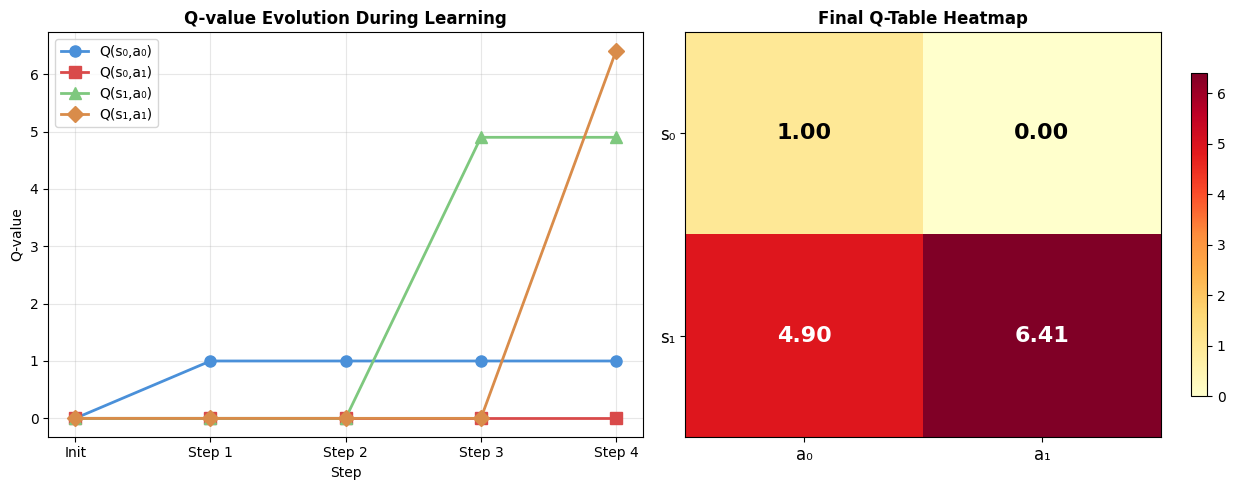

In [13]:
# ── Q4: Visualization — Q-value Evolution and Final Q-table Heatmap ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))                    # Two subplots

# --- Left: Q-value evolution across steps ---
ax1 = axes[0]                                                       # First subplot
steps_x = range(5)                                                  # 0 (init) through 4 steps
labels_sa = ['Q(s₀,a₀)', 'Q(s₀,a₁)', 'Q(s₁,a₀)', 'Q(s₁,a₁)']   # State-action pair labels
colors_q = ['#4A90D9', '#D94A4A', '#7EC87E', '#D98C4A']            # Colors for each pair
markers = ['o', 's', '^', 'D']                                     # Marker shapes

for i in range(2):                                                  # Loop over states
    for j in range(2):                                              # Loop over actions
        idx = i * 2 + j                                             # Flat index
        vals = [q_history[t][i, j] for t in range(5)]               # Q-values across steps
        ax1.plot(steps_x, vals, marker=markers[idx], label=labels_sa[idx],  # Line plot
                 color=colors_q[idx], linewidth=2, markersize=8)    # Styling

ax1.set_xlabel('Step')                                              # X-axis label
ax1.set_ylabel('Q-value')                                          # Y-axis label
ax1.set_title('Q-value Evolution During Learning', fontweight='bold')  # Title
ax1.set_xticks(range(5))                                            # Tick at each step
ax1.set_xticklabels(['Init', 'Step 1', 'Step 2', 'Step 3', 'Step 4'])  # Labels
ax1.legend(loc='upper left')                                        # Legend
ax1.grid(alpha=0.3)                                                 # Light grid

# --- Right: Final Q-table as heatmap ---
ax2 = axes[1]                                                       # Second subplot
im = ax2.imshow(Q, cmap='YlOrRd', aspect='auto')                   # Heatmap of final Q-table
ax2.set_xticks([0, 1])                                              # X ticks for actions
ax2.set_xticklabels(['a₀', 'a₁'], fontsize=12)                     # Action labels
ax2.set_yticks([0, 1])                                              # Y ticks for states
ax2.set_yticklabels(['s₀', 's₁'], fontsize=12)                     # State labels
ax2.set_title('Final Q-Table Heatmap', fontweight='bold')           # Title

# Annotate each cell with the Q-value
for i in range(2):                                                   # Loop over states
    for j in range(2):                                               # Loop over actions
        text_color = 'white' if Q[i, j] > 2 else 'black'            # Contrast text color
        ax2.text(j, i, f'{Q[i, j]:.2f}', ha='center', va='center',  # Place value in cell
                 fontsize=16, fontweight='bold', color=text_color)    # Large bold text

plt.colorbar(im, ax=ax2, shrink=0.8)                                # Add colorbar
plt.tight_layout()                                                   # Adjust layout
plt.show()                                                           # Display

### Q4(e): Discussion

**Which state-action pair ended with the highest Q-value, and why?**

The state-action pair $(s_1, a_1)$ ended with the highest Q-value of 6.41. Although action $a_1$ in state $s_1$ yields only a moderate immediate reward of 2, it transitions back to $s_1$, where the best available future action is $a_0$ with $Q(s_1, a_0) = 4.90$ (the result of Step 3). The Q-learning update therefore computed $Q(s_1, a_1) = 2 + 0.9 \times 4.90 = 6.41$. This value exceeds even $Q(s_1, a_0) = 4.90$, which has a larger immediate reward of 4 but transitions to $s_0$ where the best future Q-value is only $Q(s_0, a_0) = 1.0$. The result demonstrates a key insight of Q-learning: the action with the highest long-term value is not necessarily the one with the largest immediate reward. Instead, it is the action that leads to a state with the best future prospects, and the discount factor $\gamma$ controls how heavily those future prospects are weighted.

**How does the update rule incorporate possible future reward?**

The Q-learning update rule incorporates future reward through the term $\gamma \max_{a'} Q(s', a')$. After the agent takes action $a$ in state $s$, receives reward $r$, and arrives at next state $s'$, the algorithm looks ahead by computing the maximum Q-value achievable from $s'$ over all possible actions $a'$. This maximum is then discounted by $\gamma$ and added to the immediate reward $r$ to form the TD target $r + \gamma \max_{a'} Q(s', a')$. The key insight is that $\max_{a'} Q(s', a')$ is the agent's current best estimate of the optimal future return from the next state — it represents the value of the best possible continuation. By bootstrapping from this estimate, the update rule propagates information about future rewards backward through the state-action space, even from a single sample transition. Over many updates, this bootstrapping causes Q-values to converge toward the true optimal action-value function $Q^*$, which encodes the total discounted return from any state-action pair under the optimal policy (Sutton & Barto, 2018, Chapter 6).

**Why is Q-learning considered model-free?**

Q-learning is considered model-free because it does not require a model of the environment's transition probabilities $P(s'|s,a)$ or reward function $R(s,a)$. In contrast, model-based methods like value iteration (as we used in Question 3) require complete knowledge of these functions to compute updates by looping over all possible next states weighted by their probabilities. Q-learning bypasses this entirely by learning from actual sampled experience: the agent takes an action, observes the resulting state and reward, and updates its Q-table based on that single observed transition. It never needs to know or enumerate the full set of possible transitions — it simply learns from whatever data the environment provides. This makes Q-learning applicable in settings where the environment dynamics are unknown, too complex to specify, or even changing over time, which is a major practical advantage over model-based approaches (Sutton & Barto, 2018, Chapter 6; Russell & Norvig, 2021, Chapter 22).

---

## References

Russell, S. J., & Norvig, P. (2021). *Artificial intelligence: A modern approach* (4th ed.). Pearson. https://aima.cs.berkeley.edu/

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press. http://incompleteideas.net/book/the-book-2nd.html

Bellman, R. (1957). *Dynamic programming*. Princeton University Press. https://press.princeton.edu/books/paperback/9780691146683/dynamic-programming

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292. https://doi.org/10.1007/BF00992698